/tmp/ipykernel_3508995/558318478.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Set1')(np.linspace(0, 1, len(methods))) # 使用Set1配色，颜色更鲜明


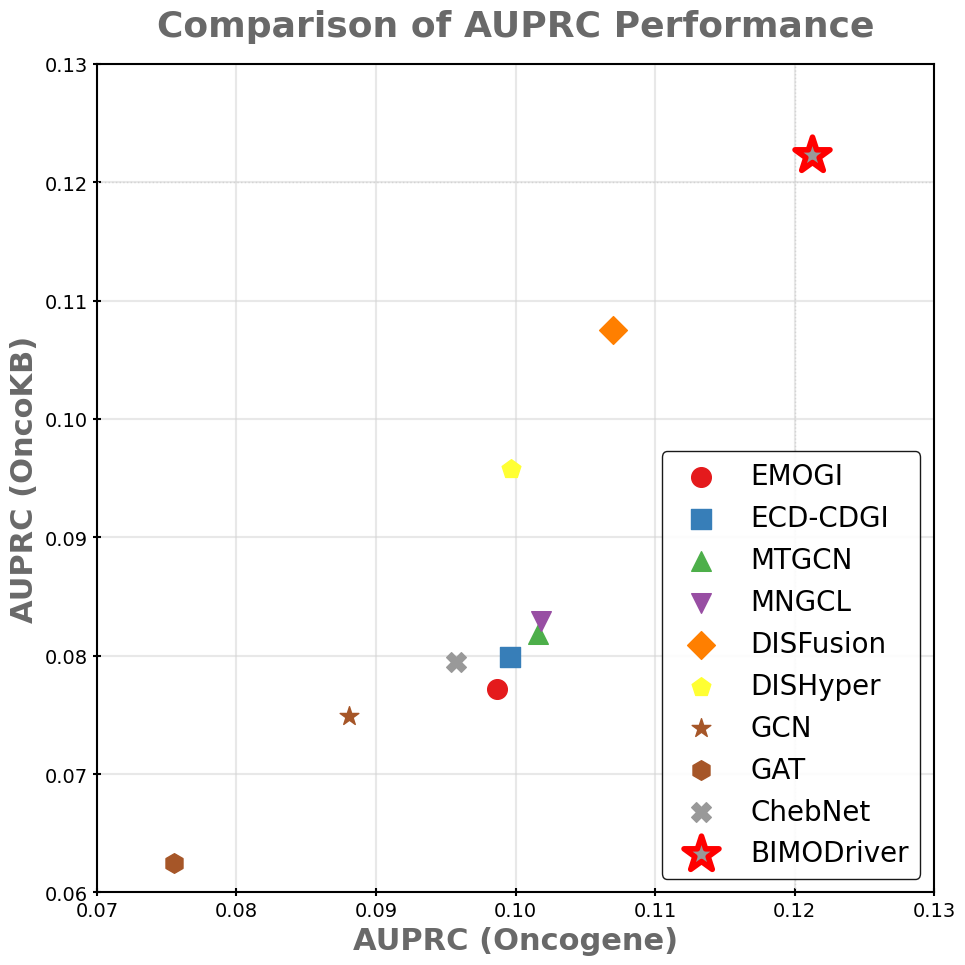

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# =====================
# Academic Style Settings (BioRender-like)
# =====================
plt.rcParams.update({
    'font.size': 18, # 基础字体增大
    'font.family': 'sans-serif',
    'axes.labelsize': 20, # 轴标签字体增大
    'axes.titlesize': 24, # 标题字体增大
    'legend.fontsize': 18, # 图例字体增大
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

# 数据
methods = ["EMOGI", "ECD-CDGI", "MTGCN", "MNGCL", "DISFusion",
           "DISHyper", "GCN", "GAT", "ChebNet", "BIMODriver"]
x_values = [0.0987, 0.0996, 0.1016, 0.1018, 0.1070, 0.0997, 0.0881, 0.0755, 0.0957, 0.1212]
y_values = [0.0772, 0.0799, 0.0818, 0.0829, 0.1075, 0.0958, 0.0749, 0.0625, 0.0795, 0.1223]

# 创建图形
plt.figure(figsize=(10, 10)) # 增大图表尺寸

# 设置背景和网格 (BioRender 风格：白色背景，清晰网格)
plt.gca().set_facecolor('white')
plt.grid(True, linestyle='-', alpha=0.5, color='lightgray', linewidth=1.5) # 增强网格线

# 定义不同的标记和颜色
markers = ['o', 's', '^', 'v', 'D', 'p', '*', 'h', 'X', '*']
colors = plt.cm.get_cmap('Set1')(np.linspace(0, 1, len(methods))) # 使用Set1配色，颜色更鲜明

# 绘制每个点
for i, (x, y) in enumerate(zip(x_values, y_values)):
    if methods[i] == "BIMODriver":
        # 显著标明BIMODriver：使用五角星标记，添加粗红色外圈，增大标记
        plt.scatter(x, y, marker='*', color=colors[i], s=700, # 增大五角星的大小
                    edgecolors='red', linewidths=4, label=methods[i], zorder=10)
        # 添加一个额外的白色外圈增强效果
        plt.scatter(x, y, marker='*', facecolors='none',
                    edgecolors='white', linewidths=2.5, s=750, zorder=9)
    else:
        plt.scatter(x, y, marker=markers[i], color=colors[i], s=200, label=methods[i], zorder=5) # 增大普通标记

# 添加最佳性能区域的标注 (可选，增强可视化)
plt.axvline(x=0.12, color='lightgrey', linestyle=':', linewidth=1)
plt.axhline(y=0.12, color='lightgrey', linestyle=':', linewidth=1)
# plt.text(0.12, 0.125, 'High Performance Zone', color='grey', fontsize=12, ha='left')

# 设置图形属性
plt.xlabel('AUPRC (Oncogene)', fontsize=22, fontweight='bold', color='dimgrey')
plt.ylabel('AUPRC (OncoKB)', fontsize=22, fontweight='bold', color='dimgrey')
plt.title('Comparison of AUPRC Performance', fontsize=26, fontweight='bold', color='dimgrey', pad=20)

# 设置坐标轴范围
plt.xlim(0.07, 0.13)
plt.ylim(0.06, 0.13)

# 坐标轴刻度线风格调整
plt.tick_params(axis='x', direction='inout', length=6, width=1.5, colors='black')
plt.tick_params(axis='y', direction='inout', length=6, width=1.5, colors='black')

# 将图例放在图表内部右下方
plt.legend(loc='lower right', # 位置不变
           ncol=1, 
           fontsize=20, # 增大图例字体
           frameon=True, # 保持图例边框
           framealpha=0.9, # 使图例背景略微透明
           edgecolor='black')

# 移除边框 (BioRender 风格通常没有外部边框)
for spine in plt.gca().spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

# 显示图形
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

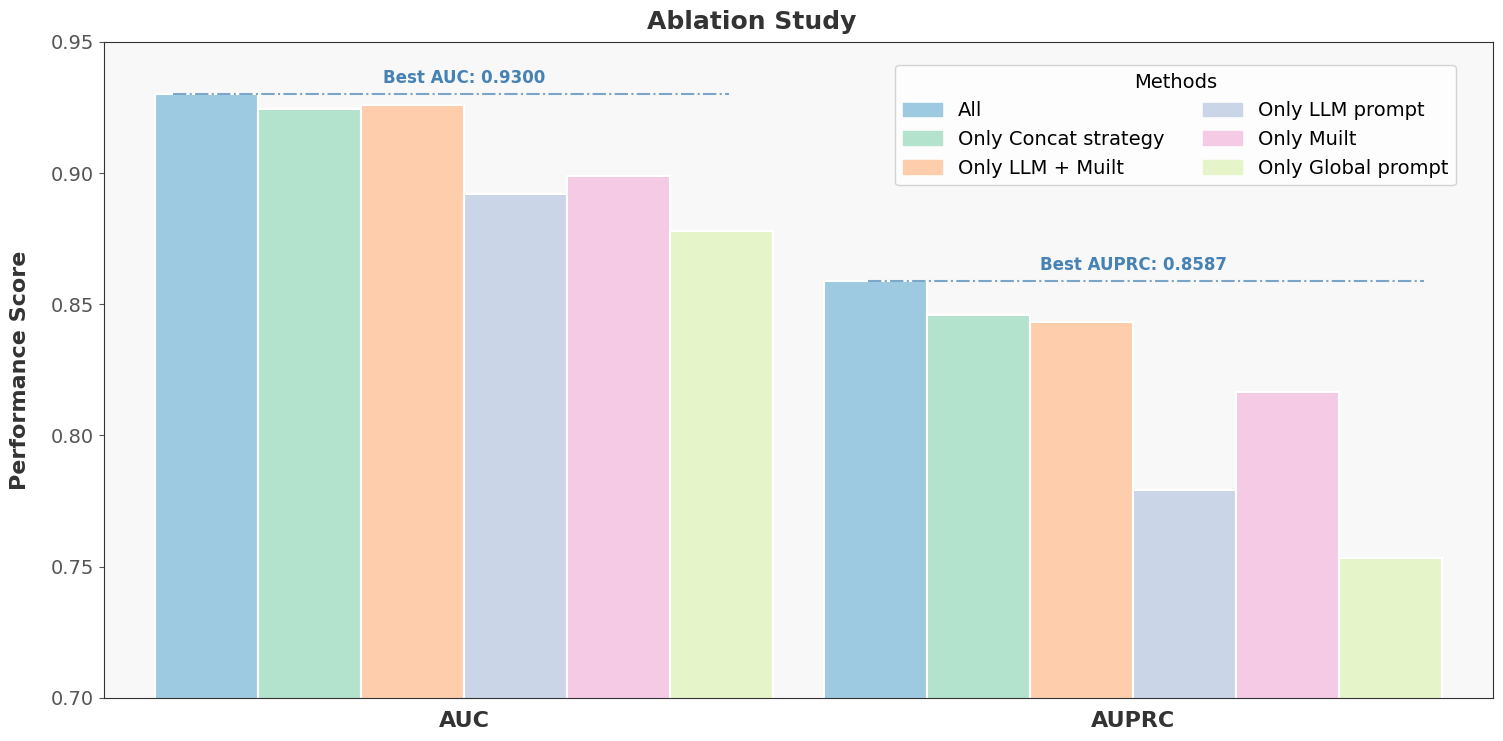

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
# 准备数据
methods = [
    # "Only Aspect prompt",
    "Only Global prompt",
    "Only Muilt",
    "Only LLM prompt",
    "Only LLM + Muilt",
    "Only Concat strategy",
    "All"
][::-1]

# 修正后的数据（根据您的数据示例）
# auc_means = [0.8342, 0.8781, 0.8990, 0.8921, 0.9260, 0.9245, 0.9292][::-1]
# auprc_means = [0.6664, 0.7534, 0.8167, 0.7793, 0.8433, 0.8460, 0.8488][::-1]
auc_means = [ 0.8781, 0.8990, 0.8921, 0.9260, 0.9245, 0.9300][::-1]
auprc_means = [0.7534, 0.8167, 0.7793, 0.8433, 0.8460, 0.8587][::-1]
# sns.set_style("whitegrid")
# 创建自定义浅色系颜色映射
light_colors = [
    '#9ecae1',  # 柔和的蓝色
    '#b3e2cd',  # 薄荷绿
    '#fdcdac',  # 淡橙色
    '#cbd5e8',  # 淡紫色
    '#f4cae4',  # 淡粉色
    '#e6f5c9',  # 浅黄绿
    '#fff2ae',  # 浅黄色
]
method_colors = {method: color for method, color in zip(methods, light_colors)}

# 设置图形参数
plt.figure(figsize=(14, 8))  # 稍微减小图形尺寸
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'DejaVu Sans',
    'axes.edgecolor': '#333333',
    'legend.framealpha': 0.85,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
})

# 创建主图框架
fig, ax = plt.subplots(figsize=(16, 8))  # 调整尺寸比例
plt.suptitle('Ablation Study', fontsize=18, weight='bold', y=0.96, color='#333333')

# 设置AUC区域为连续的柱子（宽度减半）
auc_bars = []
current_x = 0
bar_width = 0.2

# 绘制AUC柱状图（连续拼接）
for method, mean in zip(methods, auc_means):
    bar = ax.bar([current_x], [mean], width=bar_width, 
                color=method_colors[method],
                edgecolor='white',  # 添加白色边框更好区分柱子
                linewidth=1.5,      # 边框粗细
                label='AUC' if method == methods[0] else "")
    auc_bars.append(bar)
    current_x += bar_width  # 无间隔移动到下一个柱子位置

# 添加AUC区域最后一个分隔线
# ax.axvline(current_x - bar_width/2, color='#dddddd', linestyle='--', alpha=0.5, ymin=0, ymax=0.98)

# 设置AUPRC柱状图位置（在AUC右侧）
auprc_start_x = current_x + 0.1  # AUC区域后留出1单位空间
auprc_bars = []
current_x = auprc_start_x

# 绘制AUPRC柱状图（连续拼接）
for method, mean in zip(methods, auprc_means):
    bar = ax.bar([current_x], [mean], width=bar_width,
                color=method_colors[method],
                edgecolor='white',  # 添加白色边框更好区分柱子
                linewidth=1.5,      # 边框粗细
                label='AUPRC' if method == methods[0] else "")
    auprc_bars.append(bar)
    
    current_x += bar_width  # 无间隔移动到下一个柱子位置

# 添加AUPRC区域最后一个分隔线
# ax.axvline(current_x - bar_width/2, color='#dddddd', linestyle='--', alpha=0.5, ymin=0, ymax=0.98)

# 设置X轴标签和范围
ax.set_xticks([])  # 隐藏默认刻度
auc_center = (len(methods) * bar_width) / 2 - bar_width/2  # AUC区域中心位置
auprc_center = auprc_start_x + (len(methods) * bar_width) / 2 - bar_width/2  # AUPRC区域中心位置

ax.text(auc_center, -0.02, 'AUC', ha='center', va='top', 
        fontsize=16, weight='bold', color='#333333', transform=ax.get_xaxis_transform())
ax.text(auprc_center, -0.02, 'AUPRC', ha='center', va='top', 
        fontsize=16, weight='bold', color='#333333', transform=ax.get_xaxis_transform())

# 设置Y轴
ax.set_ylabel('Performance Score', fontsize=16, weight='bold', labelpad=15, color='#333333')
min_value = min(min(auc_means), min(auprc_means))
max_value = max(max(auc_means), max(auprc_means))
ax.set_ylim(min_value * 0.95, max_value * 1.05)
ax.tick_params(axis='y', colors='#555555')

# 添加方法图例（右上角）
legend_handles = [mpatches.Patch(color=method_colors[method], label=method) for method in methods]
method_legend = ax.legend(handles=legend_handles, loc='upper right', 
                         bbox_to_anchor=(0.98, 0.98),
                         ncol=2,
                         title='Methods', fontsize=14, frameon=True,
                         facecolor='white', edgecolor='#cccccc')

# 添加最佳值指示线
best_auc = max(auc_means)
best_auprc = max(auprc_means)

ax.axhline(y=best_auc, color='#4682b4', linestyle='-.', alpha=0.7, xmin=0.05, xmax=0.45)
ax.text(auc_center, best_auc + 0.003, f"Best AUC: {best_auc:.4f}", 
        ha='center', va='bottom', color='#4682b4', fontsize=12, weight='bold')

ax.axhline(y=best_auprc, color='#4682b4', linestyle='-.', alpha=0.7, xmin=0.55, xmax=0.95)
ax.text(auprc_center, best_auprc + 0.003, f"Best AUPRC: {best_auprc:.4f}", 
        ha='center', va='bottom', color='#4682b4', fontsize=12, weight='bold')


# # 设置X轴范围，确保两边有足够的空白
# ax.set_xlim(-1, current_x + 1)  # current_x是最后柱子的结束位置
ax.set_xlim(-0.2, current_x)  # current_x是最后柱子的结束位置
ax.set_ylim(0.7, 0.95)

# 调整布局
plt.tight_layout(pad=3.0)
plt.subplots_adjust(top=0.92, bottom=0.1)

# 显示图表
plt.show()

# 保存为高分辨率图像
# plt.savefig('ablation_study_results.png', dpi=3000, bbox_inches='tight', facecolor='white')

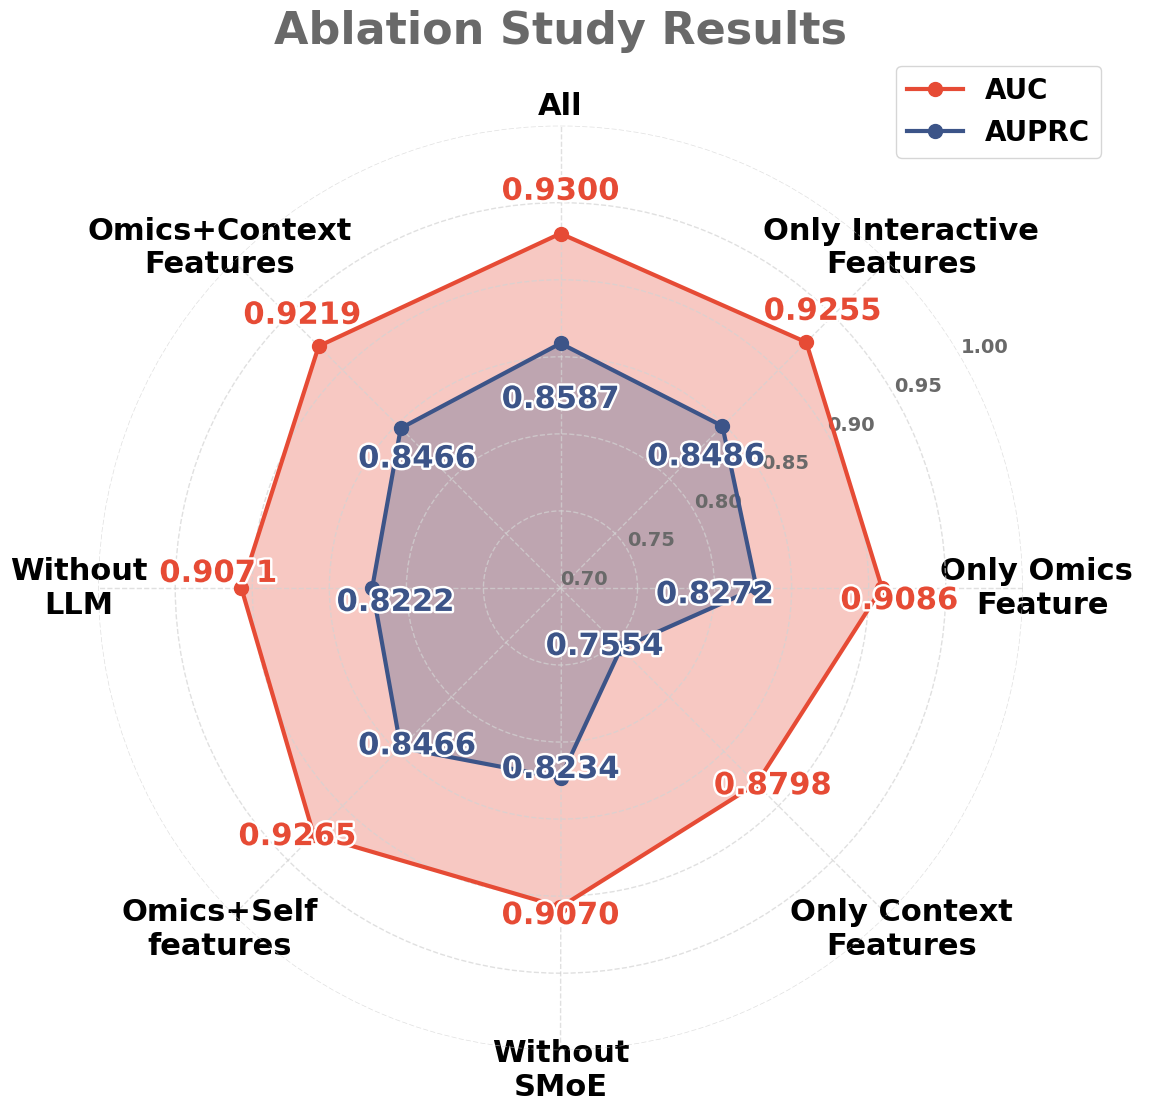

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke

# =====================
# Academic Style Settings (BioRender-like)
# =====================
plt.rcParams.update({
    'font.size': 24, # Increased font size
    'font.family': 'sans-serif', # Often used in BioRender
    'axes.labelsize': 18,
    'axes.titlesize': 28, # Increased title size
    'legend.fontsize': 20, # Increased legend size
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'font.weight': 'bold' # Make all text bold by default
})

# =====================
# Data (CPDB dataset)
# =====================
# Reorder methods as requested:
# Left: Three "Only" methods
# Right: Other methods
# Top: All
methods_left = [
    "Only Context\nFeatures",
    "Only Omics \nFeature",
    "Only Interactive\nFeatures",
]

methods_right = [
    "Omics+Context\nFeatures",
    "Without\nLLM",
    "Omics+Self\nfeatures",
    "Without\nSMoE"
]

methods = methods_left + ["All"] + methods_right

# Rearrange data according to the new order
# Original order: Only Global, Only Muilt, Only Concat, Only LLM+Muilt, Without llm, Without RAG, Without moe, All
auc_original = [0.8798, 0.9086, 0.9255, 0.9219, 0.9071, 0.9265, 0.9070, 0.9300]
auprc_original = [0.7554, 0.8272, 0.8486, 0.8466, 0.8222, 0.8466, 0.8234, 0.8587]

# New order: Only Global, Only Muilt, Only Concat, All, Only LLM+Muilt, Without llm, Without RAG, Without moe
auc_means = [auc_original[0], auc_original[1], auc_original[2], auc_original[7], auc_original[3], auc_original[4], auc_original[5], auc_original[6]]
auprc_means = [auprc_original[0], auprc_original[1], auprc_original[2], auprc_original[7], auprc_original[3], auprc_original[4], auprc_original[5], auprc_original[6]]

# =====================
# Radar Chart Plotting
# =====================
fig = plt.figure(figsize=(12, 12)) # Increased figure size
ax = fig.add_subplot(111, polar=True)

# Calculate angles - ensure "All" is at 90° (top), left methods on the left, right methods on the right
n_methods = len(methods)
angles = np.linspace(0, 2 * np.pi, n_methods, endpoint=False)

# Find the position of "All" in the list (index 3)
all_index = methods.index("All")

# Calculate the rotation angle needed to place "All" at 90° (π/2)
rotation_angle = np.pi / 2 - angles[all_index]
angles = (angles + rotation_angle) % (2 * np.pi)

angles = angles.tolist()
angles += angles[:1]  # Close the loop

# Close the data
auc_data = auc_means + [auc_means[0]]
auprc_data = auprc_means + [auprc_means[0]]

# =====================
# Plot Radar Chart
# =====================
color_auc = '#E64B35'  # BioRender-like red
color_auprc = '#3C5488' # BioRender-like blue

ax.plot(angles, auc_data, 'o-', linewidth=3, label='AUC', color=color_auc, markersize=10) # Increased linewidth and markersize
ax.fill(angles, auc_data, alpha=0.3, color=color_auc) # Slightly increased alpha
ax.plot(angles, auprc_data, 'o-', linewidth=3, label='AUPRC', color=color_auprc, markersize=10) # Increased linewidth and markersize
ax.fill(angles, auprc_data, alpha=0.3, color=color_auprc) # Slightly increased alpha

# =====================
# Polar Axis Style Optimization
# =====================
ax.set_xticks(angles[:-1])
ax.set_xticklabels(methods, fontsize=22, fontweight='bold') # Increased font size and made bold

ax.set_rlabel_position(30)
ax.set_ylim(0.7, 0.95)
ax.set_yticks(np.arange(0.7, 1.0, 0.05)) # More frequent radial ticks
ax.tick_params(axis='y', colors='dimgrey', labelsize=14) # Changed radial tick color and size

ax.set_facecolor('white')
ax.spines['polar'].set_visible(False)
ax.yaxis.grid(linestyle='--', linewidth=1, alpha=0.7, color='lightgray') # Thicker and more visible grid
ax.xaxis.grid(linestyle='--', linewidth=1, alpha=0.7, color='lightgray') # Thicker and more visible grid

# =====================
# Value Labels (Anti-overlap + Stroke)
# =====================
outline = withStroke(linewidth=3.5, foreground="white") # Increased outline thickness

for i, (angle, auc_val, auprc_val, label) in enumerate(zip(angles[:-1], auc_means, auprc_means, methods)):
    r_offset = 0.015 # Increased offset
    
    # Adjust label position based on location to avoid overlap
    if "All" in label:  # Top label
        ax.text(angle, auc_val + r_offset * 1.2, f'{auc_val:.4f}',
                ha='center', va='bottom', fontsize=22, color=color_auc, # Increased font size
                fontweight='bold', path_effects=[outline])
        ax.text(angle, auprc_val - r_offset * 1.8, f'{auprc_val:.4f}',
                ha='center', va='top', fontsize=22, color=color_auprc, # Increased font size
                fontweight='bold', path_effects=[outline])
    elif "Only Concat\nstrategy" in label:  # Specific optimization for this label
        # Move AUC value inwards, text outwards
        ax.text(angle, auc_val - r_offset * 1.0, f'{auc_val:.4f}',
                ha='center', va='center', fontsize=22, color=color_auc, # Increased font size
                fontweight='bold', path_effects=[outline])
        ax.text(angle, auprc_val - r_offset * 2.0, f'{auprc_val:.4f}',
                ha='center', va='top', fontsize=22, color=color_auprc, # Increased font size
                fontweight='bold', path_effects=[outline])
    elif "Only LLM +\nMuilt" in label:
        ax.text(angle - 0.05, auc_val + r_offset * 0.8, f'{auc_val:.4f}',
                ha='center', va='bottom', fontsize=22, color=color_auc,
                fontweight='bold', path_effects=[outline])
        ax.text(angle + 0.05, auprc_val - r_offset * 1.8, f'{auprc_val:.4f}',
                ha='center', va='top', fontsize=22, color=color_auprc,
                fontweight='bold', path_effects=[outline])
    elif "Only Omics \nFeature" in label:
        ax.text(angle - 0.08, auc_val + r_offset * 0.8, f'{auc_val:.4f}',
                ha='center', va='bottom', fontsize=22, color=color_auc,
                fontweight='bold', path_effects=[outline])
        ax.text(angle + 0.05, auprc_val - r_offset * 1.8, f'{auprc_val:.4f}',
                ha='center', va='top', fontsize=22, color=color_auprc,
                fontweight='bold', path_effects=[outline])
    else:  # Other labels
        ax.text(angle, auc_val + r_offset, f'{auc_val:.4f}',
                ha='center', va='bottom', fontsize=22, color=color_auc, # Increased font size
                fontweight='bold', path_effects=[outline])
        ax.text(angle, auprc_val - r_offset, f'{auprc_val:.4f}',
                ha='center', va='top', fontsize=22, color=color_auprc, # Increased font size
                fontweight='bold', path_effects=[outline])

# =====================
# Legend and Title
# =====================
ax.legend(loc='upper right', bbox_to_anchor=(1.10, 1.08)) # Adjusted legend position
plt.title('Ablation Study Results', size=32, fontweight='bold', y=1.08, color='dimgrey') # Increased title size and changed color

plt.tight_layout()
plt.show()